In [2]:
import os
import copy
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, f1_score

In [3]:
data = pd.read_csv('illness_dataset.csv')

In [4]:
data.head()

,Disease,muscle_tension,low_energy,sleep_disturbances,changes_in_weight,difficulty_concentrating,feeling_of_worthless,low_mood,irritability,thoughts_of_death,...,inability_to_recall_important_personal_information,memory_loss_typically_related_to_trauma,sudden_onset_of_amnesia,gaps_in_memory_for_long_periods_of_time,wandering,loss_of_identity,emotional_numbness,trouble_remembering_daily_tasks,anxiety_related_to_memory_loss,confusion
0,Borderline Personality Disorder,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Eating Disorder,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Major Depressive Disorder,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,Substance Use Disorder,0,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ADHD (Attention Deficit Hyperactivity Disorder),0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<h2>Preprocesiranje</h2>

In [5]:
data.isna().sum().sum()

0

In [6]:
X = data.drop(columns=['Disease'])
Y = data['Disease']

In [7]:
X.shape

(8304, 185)

In [8]:
Y.shape

(8304,)

In [9]:
Y.value_counts()

Disease
Major Depressive Disorder                          392
Dissociative Amnesia                               391
Separation Anxiety Disorder                        390
Obsessive-Compulsive Disorder (OCD)                390
ADHD (Attention Deficit Hyperactivity Disorder)    390
Autism Spectrum Disorder                           388
Insomnia                                           388
Bipolar Disorder                                   388
Borderline Personality Disorder                    387
Eating Disorder                                    386
Panic Disorder                                     385
Generalized Anxiety Disorder (GAD)                 385
Schizophrenia                                      385
Social Anxiety Disorder                            385
Dissociative Identity Disorder                     385
Post-Traumatic Stress Disorder (PTSD)              384
Substance Use Disorder                             383
Persistent Depressive Disorder                     383
De

In [10]:
pd.DataFrame(Y).head()

,Disease
0,Borderline Personality Disorder
1,Eating Disorder
2,Major Depressive Disorder
3,Substance Use Disorder
4,ADHD (Attention Deficit Hyperactivity Disorder)


In [11]:
encoder = LabelEncoder()

In [12]:
feature_names = X.columns

In [13]:
feature_names

Index(['muscle_tension', 'low_energy', 'sleep_disturbances',
       'changes_in_weight', 'difficulty_concentrating', 'feeling_of_worthless',
       'low_mood', 'irritability', 'thoughts_of_death',
       'physical_aches_and_pains',
       ...
       'inability_to_recall_important_personal_information',
       'memory_loss_typically_related_to_trauma', 'sudden_onset_of_amnesia',
       'gaps_in_memory_for_long_periods_of_time', 'wandering',
       'loss_of_identity', 'emotional_numbness',
       'trouble_remembering_daily_tasks', 'anxiety_related_to_memory_loss',
       'confusion'],
      dtype='object', length=185)

In [14]:
Y = encoder.fit_transform(Y)

In [15]:
Y

array([ 5,  9, 12, ..., 10, 15, 12])

In [16]:
data_preprocessed = X.copy()
data_preprocessed['Target_Disease'] = Y
data_preprocessed.to_csv('podaci_preprocesirani.csv', index=False)

<h2>Reprezentacija podataka u 3D</h2>

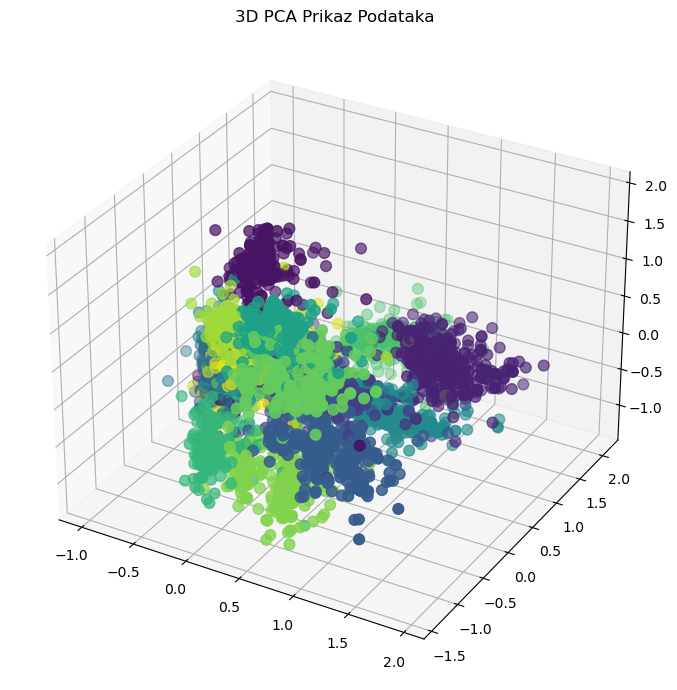

In [17]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=Y, cmap='viridis', s=60)
ax.set_title('3D PCA Prikaz Podataka')
plt.tight_layout()
plt.savefig('vizuelizacija_3d.png')
plt.show()

In [18]:
X_all = X

k_best = min(15, X.shape[1])
selector = SelectKBest(score_func=chi2, k=k_best)
X_kbest = selector.fit_transform(X, Y)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)

attribute_sets = {
    'Svi Atributi': X_all,
    'SelectKBest (Top 15)': X_kbest,
    'PCA (10 Komponenti)': X_pca
}

In [19]:
classifiers = {
    'Random Forest': RandomForestClassifier(random_state=8),
    'SVM': SVC(kernel='linear', random_state=8),
    'Decision Tree': DecisionTreeClassifier(max_depth=25, random_state=8),
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'BernoulliNB' : BernoulliNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=8)
}

In [20]:
results = []
trained_models = {}

In [21]:
os.makedirs('modeli', exist_ok=True)

In [22]:
for set_name, X_set in attribute_sets.items():
    X_train, X_test, y_train, y_test = train_test_split(X_set, Y, test_size=0.3, random_state=42, stratify=Y)
    
    for clf_name, clf in classifiers.items():
        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        results.append({
            'Skup Atributa': set_name,
            'Algoritam': clf_name,
            'Accuracy': acc,
            'F1-Score': f1
        })
        
        model_filename = f"modeli/{clf_name.replace(' ', '_')}_{set_name.replace(' ', '_')}.pkl"
        joblib.dump(clf, model_filename)

        trained_models[(set_name, clf_name)] = copy.deepcopy(clf)
        

In [23]:
results_df = pd.DataFrame(results)
results_df

,Skup Atributa,Algoritam,Accuracy,F1-Score
0,Svi Atributi,Random Forest,0.972311,0.971641
1,Svi Atributi,SVM,0.972713,0.972700
2,Svi Atributi,Decision Tree,0.626404,0.700447
3,Svi Atributi,KNN,0.975522,0.976027
4,Svi Atributi,BernoulliNB,0.972713,0.971850
5,Svi Atributi,Logistic Regression,0.974719,0.974749
6,SelectKBest (Top 15),Random Forest,0.391252,0.369965
7,SelectKBest (Top 15),SVM,0.391653,0.369584
8,SelectKBest (Top 15),Decision Tree,0.390449,0.369141
9,SelectKBest (Top 15),KNN,0.387239,0.368028


In [34]:
results_df.to_csv('rezultati_poredjenja.csv', index=False)

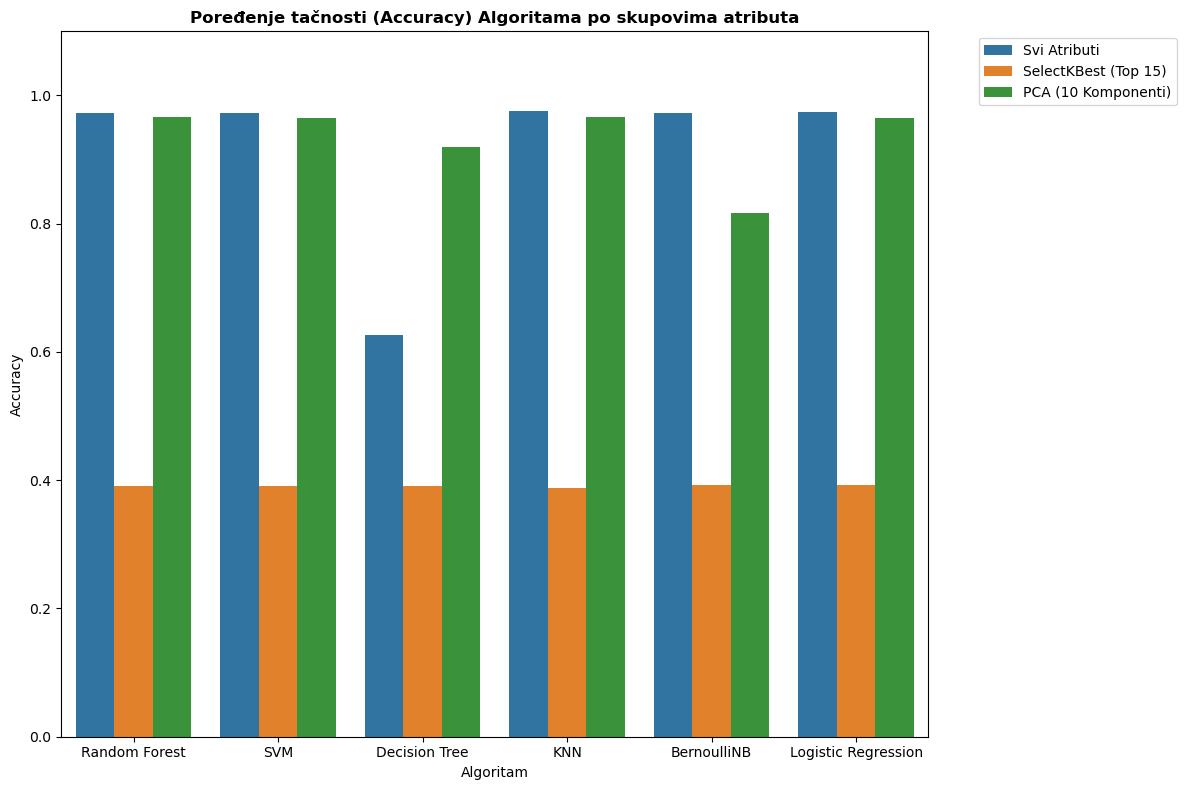

In [25]:
plt.figure(figsize=(12, 8))
sns.barplot(data=results_df, x='Algoritam', y='Accuracy', hue='Skup Atributa')
plt.title('Poređenje tačnosti (Accuracy) Algoritama po skupovima atributa', fontweight='bold')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('poredjenje_modela.png')
plt.show()

In [30]:
def plot_illness_importance(model, X_vals, i, illness):
    coeffs = model.coef_[i]

    df = pd.DataFrame({
        "feature": X_vals.columns,
        "importance": coeffs
    }).sort_values("importance", ascending=False).head(10)

    plt.figure(figsize=(8, 3))

    plt.barh(df["feature"][::-1], df["importance"][::-1])

    plt.title(f"Top 10 Features - {illness}")
    plt.xlabel("Coefficient importance")

    plt.tight_layout()
    plt.show()

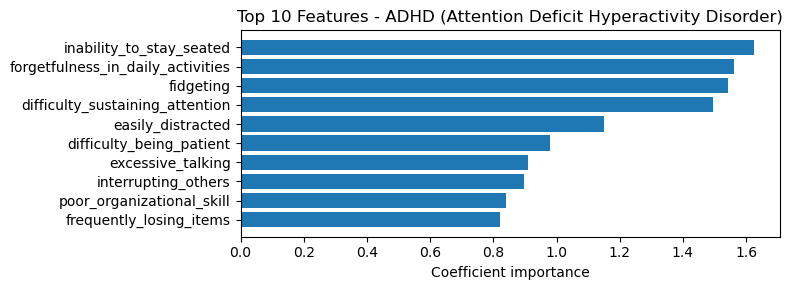

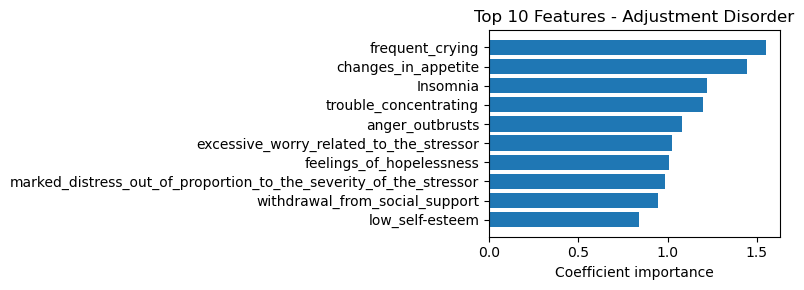

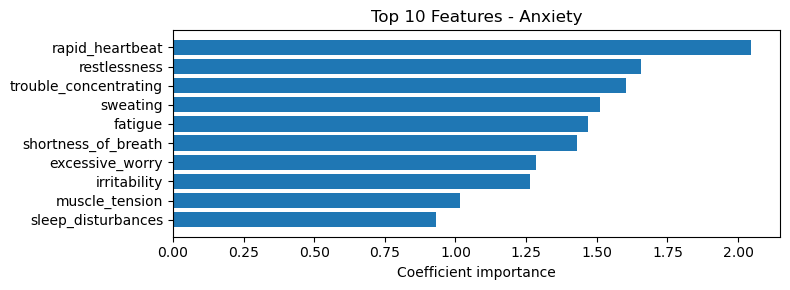

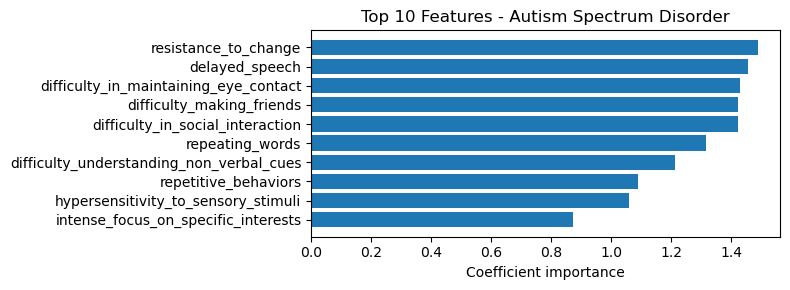

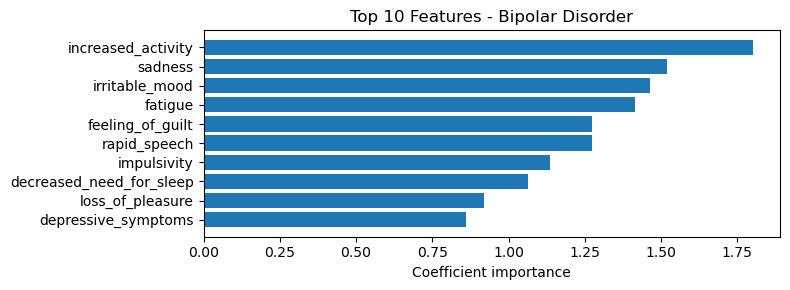

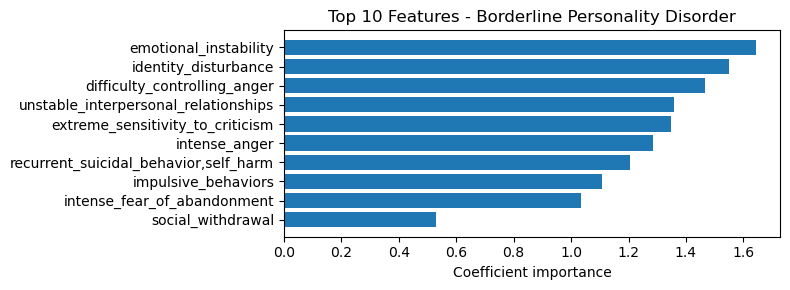

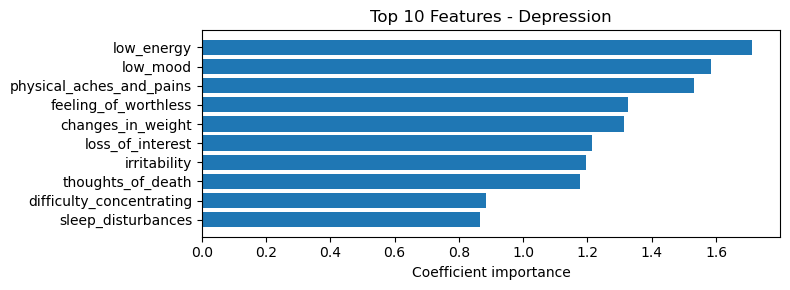

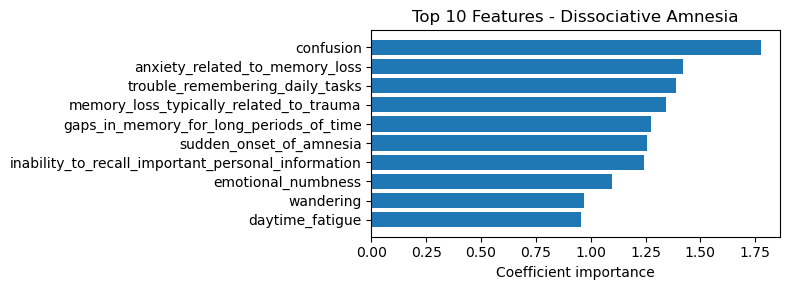

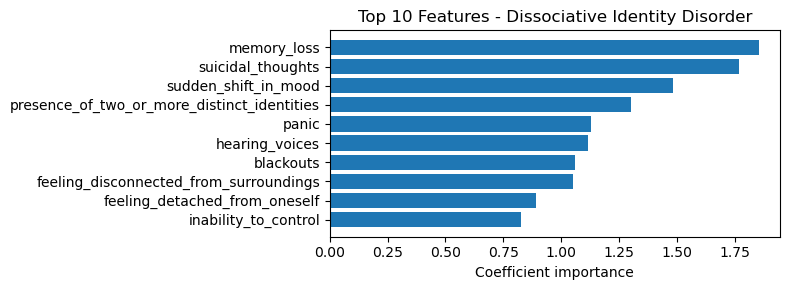

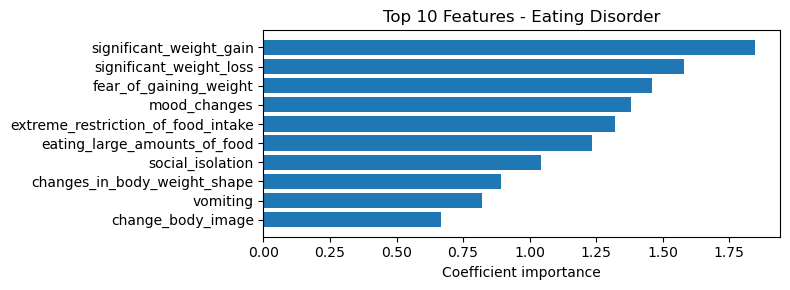

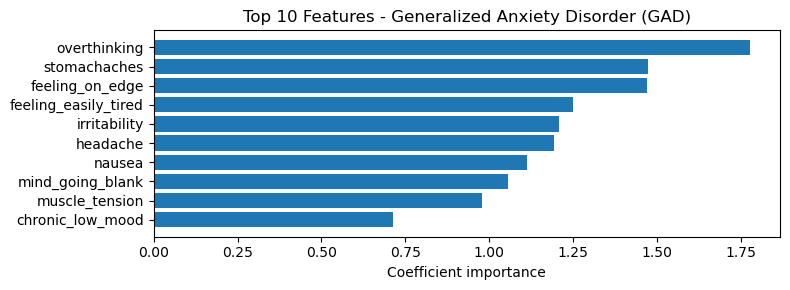

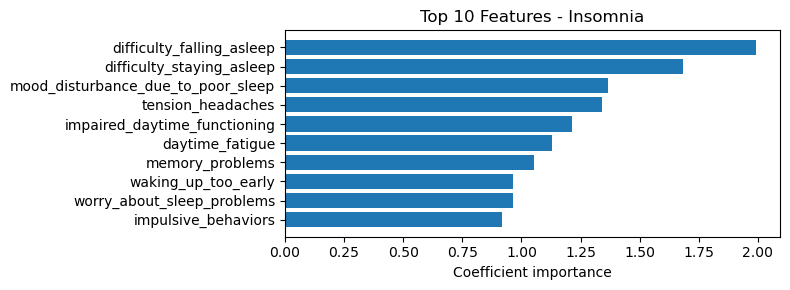

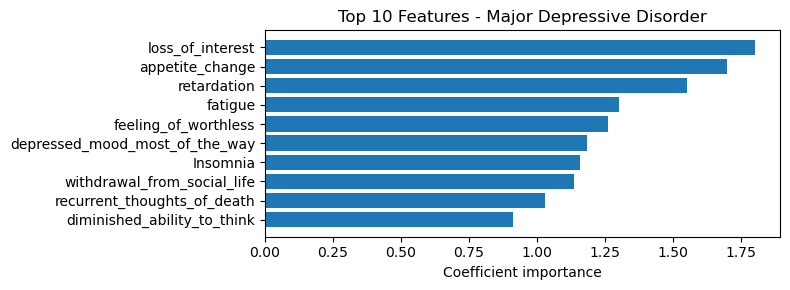

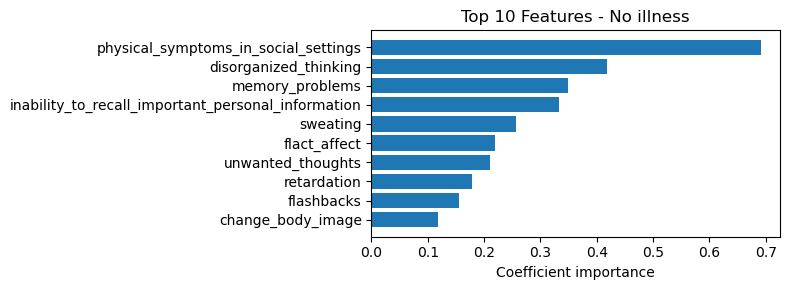

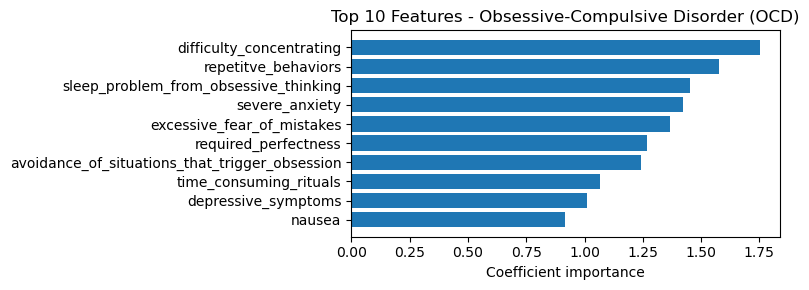

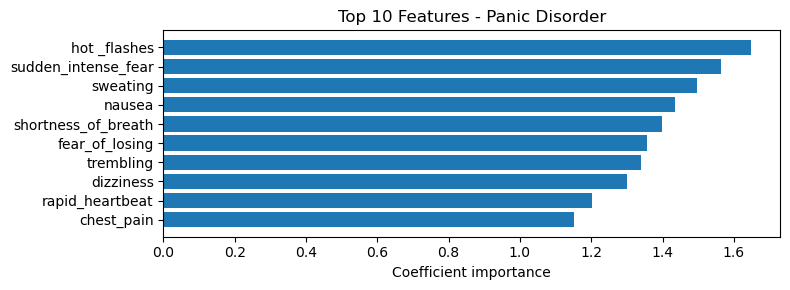

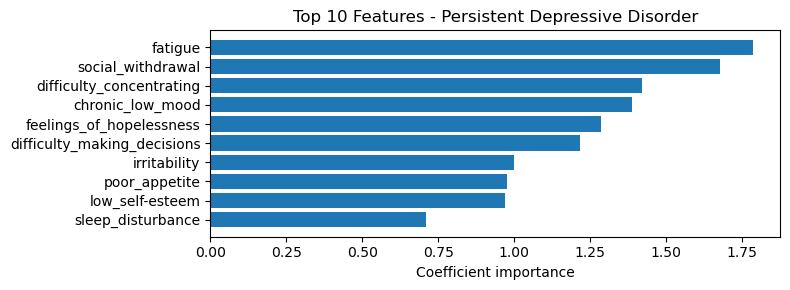

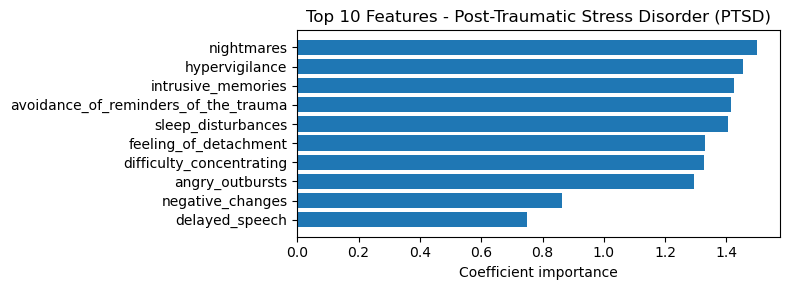

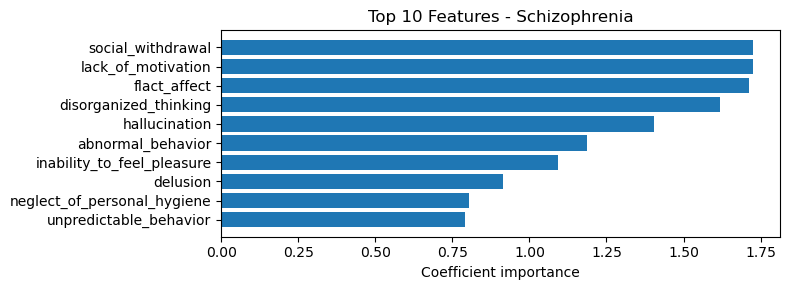

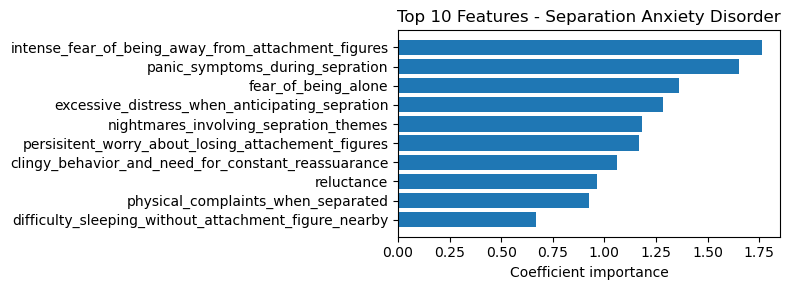

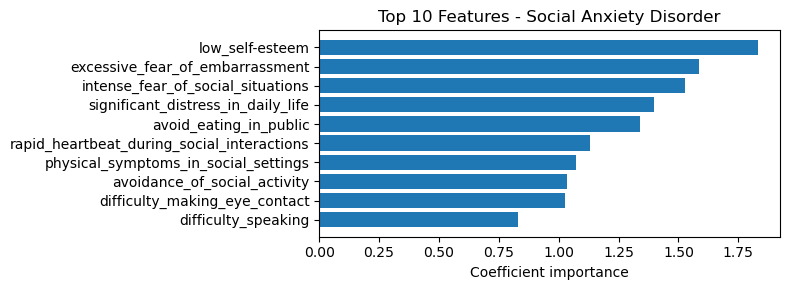

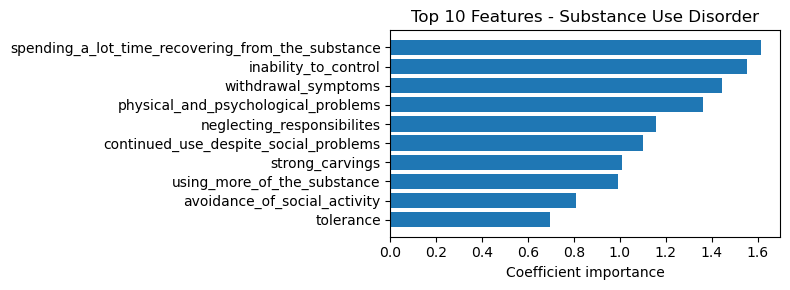

In [32]:
for i, illness in enumerate(encoder.classes_):
    plot_illness_importance(trained_models[('Svi Atributi','Logistic Regression')], attribute_sets['Svi Atributi'], i, illness)

In [33]:
bpd_df = data[data["Disease"] == "Borderline Personality Disorder"]
percent = (bpd_df["persisitent_worry_about_losing_attachement_figures"] == 0).mean() * 100
print(percent)

98.44961240310077
